# Calculate scaling factors for self-heating correction of open-path fluxes from parallel measurements (NEE)
- Here the scaling factors are calculated from parallel measurements
- Scaling factors are determined in 20 classes of USTAR, separately for daytime and nighttime data
- The scaling factors corresponds to the fraction of the (unscaled) flux correction term that is added to the measured open-path flux NEE

# Imports

In [1]:
from datetime import datetime
import pandas as pd
from diive.core.io.files import save_parquet, load_parquet
from diive.pkgs.flux.selfheating import ScopPhysics, ScopOptimizer, ScopApplicator

# Docstring

In [2]:
help(ScopPhysics)

Help on class ScopPhysics in module diive.pkgs.flux.selfheating:

class ScopPhysics(builtins.object)
 |  ScopPhysics(flux_type: Literal['CO2', 'H2O'], ta: pandas.core.series.Series, gas_density: pandas.core.series.Series, rho_a: pandas.core.series.Series, rho_v: pandas.core.series.Series, u: pandas.core.series.Series, c_p: pandas.core.series.Series, ustar: pandas.core.series.Series, swin: pandas.core.series.Series, lat: float, lon: float, utc_offset: int, remove_outliers_method: Literal['fast', 'separate'] = 'fast')
 |  
 |  Methods defined here:
 |  
 |  __init__(self, flux_type: Literal['CO2', 'H2O'], ta: pandas.core.series.Series, gas_density: pandas.core.series.Series, rho_a: pandas.core.series.Series, rho_v: pandas.core.series.Series, u: pandas.core.series.Series, c_p: pandas.core.series.Series, ustar: pandas.core.series.Series, swin: pandas.core.series.Series, lat: float, lon: float, utc_offset: int, remove_outliers_method: Literal['fast', 'separate'] = 'fast')
 |      Args:
 |  

# Load data

In [3]:
df = load_parquet(filepath=r"22_MERGED_IRGA75-noSHC+IRGA72_FluxProcessingChain_after-L3.2_NEE-QCF10_LE-QCF11_2016-2017.parquet")

# Parallel measurements starting 27 May 2016
df = df.loc["2016-05-27 00:15:00":"2017-12-11 23:45:00"].copy()
df.describe()

Loaded .parquet file 22_MERGED_IRGA75-noSHC+IRGA72_FluxProcessingChain_after-L3.2_NEE-QCF10_LE-QCF11_2016-2017.parquet (0.047 seconds).
    --> Detected time resolution of <30 * Minutes> / 30min 


,NEE_L3.1_L3.2_QCF_IRGA72,CO2_MOLAR_DENSITY_IRGA72,AIR_CP_IRGA72,AIR_DENSITY_IRGA72,VAPOR_DENSITY_IRGA72,U_IRGA72,USTAR_IRGA72,...,RH_T1_47_1_IRGA72,LE_L3.1_L3.2_QCF_IRGA72,H2O_MOLAR_DENSITY_IRGA72,NEE_L3.1_L3.2_QCF_IRGA75,CO2_MOLAR_DENSITY_IRGA75,LE_L3.1_L3.2_QCF_IRGA75,H2O_MOLAR_DENSITY_IRGA75
count,13641.000000,26764.000000,26820.000000,26820.000000,26820.000000,26820.000000,26820.000000,...,27068.000000,18299.000000,26764.000000,11837.000000,25019.000000,16516.000000,23668.000000
mean,-4.141616,15.664632,1011.836159,1.140542,0.008346,2.410021,0.462083,...,80.276518,74.772872,458.021998,-7.360489,16.429453,87.143241,467.825479
std,10.576006,0.914060,2.839646,0.037321,0.003236,1.674600,0.291712,...,18.376039,120.386423,178.895017,11.217378,2.181614,126.282900,182.132359
min,-49.982370,13.512800,1006.370000,1.058090,0.001956,0.009557,0.009705,...,22.011724,-49.954200,106.438000,-48.713570,8.497130,-49.981648,108.537000
25%,-9.837730,14.973475,1009.390000,1.112630,0.005525,1.155638,0.237527,...,66.131050,0.795993,302.377500,-14.141190,15.233650,5.604558,306.895000
50%,-1.079220,15.606650,1011.670000,1.136255,0.008196,2.050895,0.406006,...,83.558506,17.902850,447.727500,-4.903080,15.913500,29.994410,463.384000
75%,2.600789,16.251125,1014.050000,1.166620,0.010886,3.276645,0.623035,...,99.017420,104.668460,599.283750,0.529420,16.769600,126.293390,612.300750
max,38.419780,19.405300,1020.570000,1.259900,0.017989,11.932600,2.898660,...,99.864659,740.762170,987.199000,29.506870,33.979700,859.062300,998.288000


# Calculate unscaled flux correction term with `ScopPhysics`

In [4]:
physics = ScopPhysics(
    flux_type="CO2",
    ta=df["TA_T1_47_1_gfXG_IRGA72"].copy(),
    gas_density=df["CO2_MOLAR_DENSITY_IRGA75"].copy() * 1000,  # Requires umol m-3
    rho_a=df["AIR_DENSITY_IRGA72"].copy(),
    rho_v=df["VAPOR_DENSITY_IRGA72"].copy(),
    u=df["U_IRGA72"].copy(),
    c_p=df["AIR_CP_IRGA72"].copy(),
    ustar=df["USTAR_IRGA72"].copy(),
    swin=df["SW_IN_T1_47_1_gfXG_IRGA72"].copy(),
    lat=47.478333,  # CH–LAE
    lon=8.364389,  # CH–LAE
    utc_offset=1,
)
physics.run(correction_method_base="JAR09", gapfill=True)
results_physics_df = physics.get_results()

Aerodynamic resistance: Mean = 28.58 s m-1
Dry air density: Mean = 1.1322 kg m-3


Starting gap-filling for
FCT_UNSC
using <class 'sklearn.ensemble._forest.RandomForestRegressor'>

Adding new data columns ...
++ Added new columns with lagged variants for: ['TA_T1_47_1_gfXG_IRGA72', 'AIR_CP_IRGA72', 'AIR_DENSITY_IRGA72', 'U_IRGA72', 'USTAR_IRGA72'] (lags between -1 and -1 with stepsize 1), no lagged variants for: ['FCT_UNSC']. Shifting the time series created gaps which were then filled with the nearest value.
++ Added new columns with timestamp info: ['.YEAR', '.SEASON', '.SEASON_SIN', '.SEASON_COS', '.MONTH', '.MONTH_SIN', '.MONTH_COS', '.WEEK', '.WEEK_SIN', '.WEEK_COS', '.DOY', '.DOY_SIN', '.DOY_COS', '.HOUR', '.HOUR_SIN', '.HOUR_COS', '.YEARMONTH', '.YEARDOY', '.YEARWEEK'] 
++ Added new column .RECORDNUMBER with record numbers from 1 to 21842.

Sanitizing timestamp ...
>>> Validating timestamp naming of timestamp column TIMESTAMP_MIDDLE ... Timestamp name OK.
>>> Converting timestam

In [5]:
results_physics_df.describe()

,FCT_UNSC_gfRF,FCT_UNSC,TS,TA_T1_47_1_gfXG_IRGA72,AIR_CP_IRGA72,AERODYNAMIC_RESISTANCE,AIR_DENSITY_IRGA72,...,U_IRGA72,USTAR_IRGA72,CO2_MOLAR_DENSITY_IRGA75,SW_IN_T1_47_1_gfXG_IRGA72,AIR_THERMAL_CONDUCTIVITY,DAYTIME,LATENT_HEAT_VAPORIZATION_J_UMOL
count,27072.000000,21842.000000,27072.000000,27072.000000,26820.000000,24328.000000,26820.000000,...,26820.000000,26820.000000,25019.000000,27072.000000,27072.000000,27072.000000,27072.000000
mean,13.797929,13.957498,13.153032,11.078826,1011.836159,14.577003,1.140542,...,2.410021,0.462083,16429.453030,159.705284,0.025026,0.460254,0.044583
std,10.649169,11.329005,8.445643,8.449951,2.839646,12.580901,0.037321,...,1.674600,0.291712,2181.613628,253.880454,0.000591,0.498427,0.000361
min,0.872043,0.872043,-11.259381,-12.170839,1006.370000,0.051142,1.058090,...,0.009557,0.009705,8497.130000,0.000000,0.023398,0.000000,0.043664
25%,6.354050,5.818585,6.709264,4.551228,1009.390000,6.010944,1.112630,...,1.155638,0.237527,15233.650000,0.000000,0.024569,0.000000,0.044313
50%,10.899619,10.701315,13.894836,11.682467,1011.670000,10.244472,1.136255,...,2.050895,0.406006,15913.500000,0.000000,0.025068,0.000000,0.044557
75%,17.906489,18.416829,19.556348,17.409318,1014.050000,18.728289,1.166620,...,3.276645,0.623035,16769.600000,231.844643,0.025469,1.000000,0.044862
max,79.894031,79.894031,33.492252,32.604572,1020.570000,85.899441,1.259900,...,11.932600,2.898660,33979.700000,1110.706662,0.026532,1.000000,0.045576


Plotting Physics Diel Cycles...


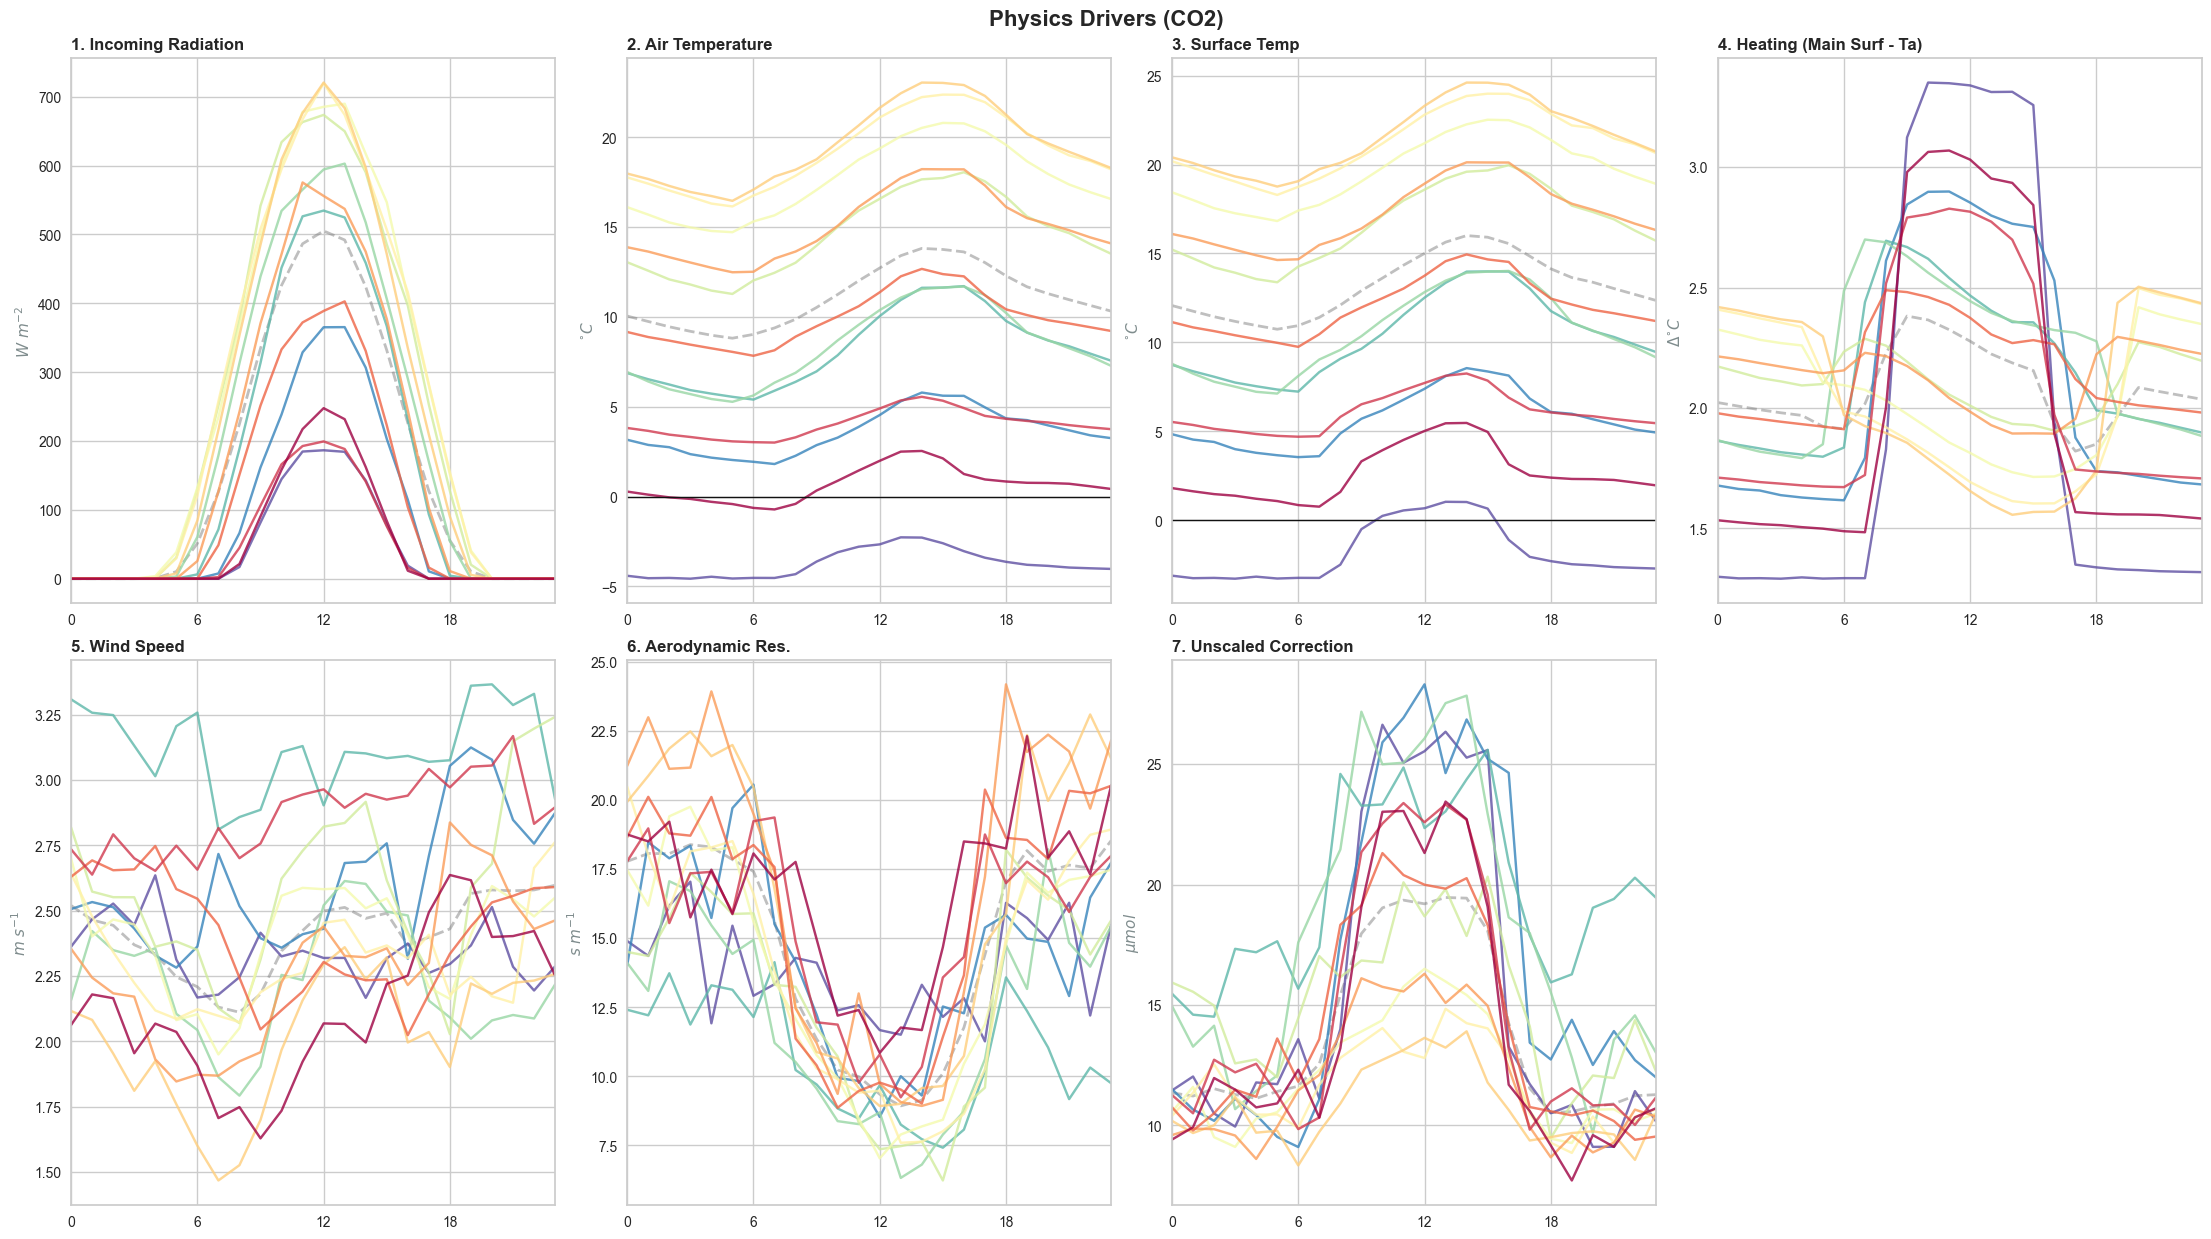

In [6]:
physics.plot_diel_cycles()

# Optimize scaling factors with `ScopOptimizer`

Finished group 0.0 (Daytime 0.0): Median SF = 0.056
Finished group 1.0 (Daytime 0.0): Median SF = 0.238
Finished group 2.0 (Daytime 0.0): Median SF = 0.309
Finished group 3.0 (Daytime 0.0): Median SF = 0.126
Finished group 4.0 (Daytime 0.0): Median SF = 0.389
Finished group 5.0 (Daytime 0.0): Median SF = 0.093
Finished group 6.0 (Daytime 0.0): Median SF = 0.164
Finished group 7.0 (Daytime 0.0): Median SF = 0.105
Finished group 8.0 (Daytime 0.0): Median SF = 0.166
Finished group 9.0 (Daytime 0.0): Median SF = 0.117
Finished group 10.0 (Daytime 0.0): Median SF = 0.142
Finished group 11.0 (Daytime 0.0): Median SF = 0.145
Finished group 12.0 (Daytime 0.0): Median SF = 0.108
Finished group 13.0 (Daytime 0.0): Median SF = 0.089
Finished group 14.0 (Daytime 0.0): Median SF = 0.097
Finished group 15.0 (Daytime 0.0): Median SF = 0.100
Finished group 16.0 (Daytime 0.0): Median SF = 0.134
Finished group 17.0 (Daytime 0.0): Median SF = 0.054
Finished group 18.0 (Daytime 0.0): Median SF = 0.065
Fin

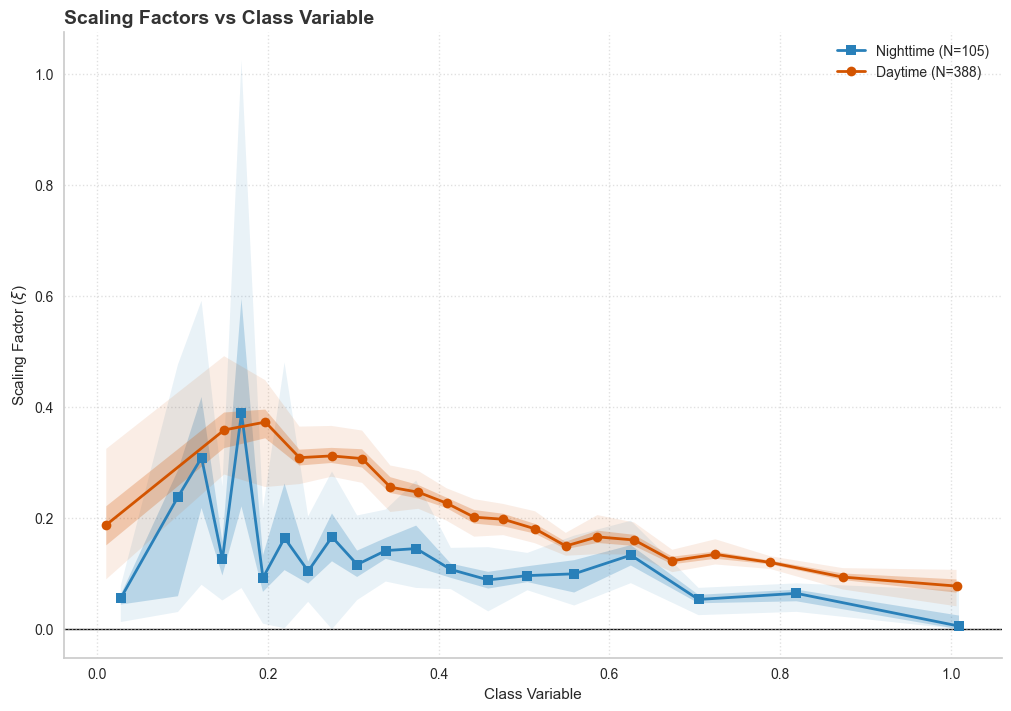

In [7]:
optimizer = ScopOptimizer(
    flux_type="CO2",
    fct_unsc=results_physics_df["FCT_UNSC_gfRF"],
    class_var=df["USTAR_IRGA72"].copy(),
    n_classes=20,
    n_bootstrap_runs=100,
    flux_openpath=df["NEE_L3.1_L3.2_QCF_IRGA75"].copy(),
    flux_closedpath=df["NEE_L3.1_L3.2_QCF_IRGA72"].copy(),
    daytime=results_physics_df["DAYTIME"]
)
scaling_factors_df = optimizer.run()
optimizer.stats()
optimizer.plot()

In [8]:
scaling_factors_df.describe()

,DAYTIME,GROUP_CLASSVAR,GROUP_CLASSVAR_MIN,GROUP_CLASSVAR_MAX,BOOTSTRAP_RUNS,SF_MEDIAN,SF_Q25,SF_Q75,SF_Q01,SF_Q99,SOS_MEDIAN,NUMVALS_AVG
count,40.00000,40.00000,40.000000,40.000000,40.0,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000,40.000000
mean,0.50000,9.50000,0.429311,0.518413,100.0,0.172235,0.145040,0.199113,0.106630,0.260315,4212.113597,246.675000
std,0.50637,5.83974,0.258778,0.386932,0.0,0.094719,0.085466,0.115631,0.083636,0.176978,3612.156012,148.702661
min,0.00000,0.00000,0.010718,0.092605,100.0,0.005713,0.000006,0.024691,0.000006,0.070268,42.326613,32.000000
25%,0.00000,4.75000,0.232607,0.267238,100.0,0.103499,0.084278,0.123234,0.042449,0.147555,772.133458,122.500000
50%,0.50000,9.50000,0.392778,0.427828,100.0,0.147685,0.119693,0.167318,0.081600,0.214096,3250.668361,243.000000
75%,1.00000,14.25000,0.595706,0.640112,100.0,0.229947,0.197378,0.260460,0.157886,0.302463,7489.456509,392.750000
max,1.00000,19.00000,1.009440,1.966410,100.0,0.389207,0.343994,0.595500,0.278707,1.025125,11238.947693,426.000000


In [9]:
optimizer.stats()



                    SCALING FACTOR OPTIMIZATION REPORT                     
Flux Type      : CO2
Bootstrap Runs : 100
Total Bins     : 40
---------------------------------------------------------------------------
1. GLOBAL SUMMARY (Median of Bins)      
...........................................................................
Period          |  Median SF | Mean Uncertainty (IQR) |    N_Avg
Nighttime       |      0.112 |                  0.081 |      105
Daytime         |      0.193 |                  0.027 |      388


2. DETAILED BIN BREAKDOWN               
...........................................................................
Bin  |     Class Range     |     N |    Median SF (ξ) |      99% CI      | Error (SOS)
---------------------------------------------------------------------------
--- DAYTIME ---
0    |     0.01 - 0.15     |   340 |            0.188 |   [0.09-0.32]    |    9780.03
1    |     0.15 - 0.20     |   364 |            0.359 |   [0.28-0.49]    |    8893.01
2 

Plotting Scaling Factors...


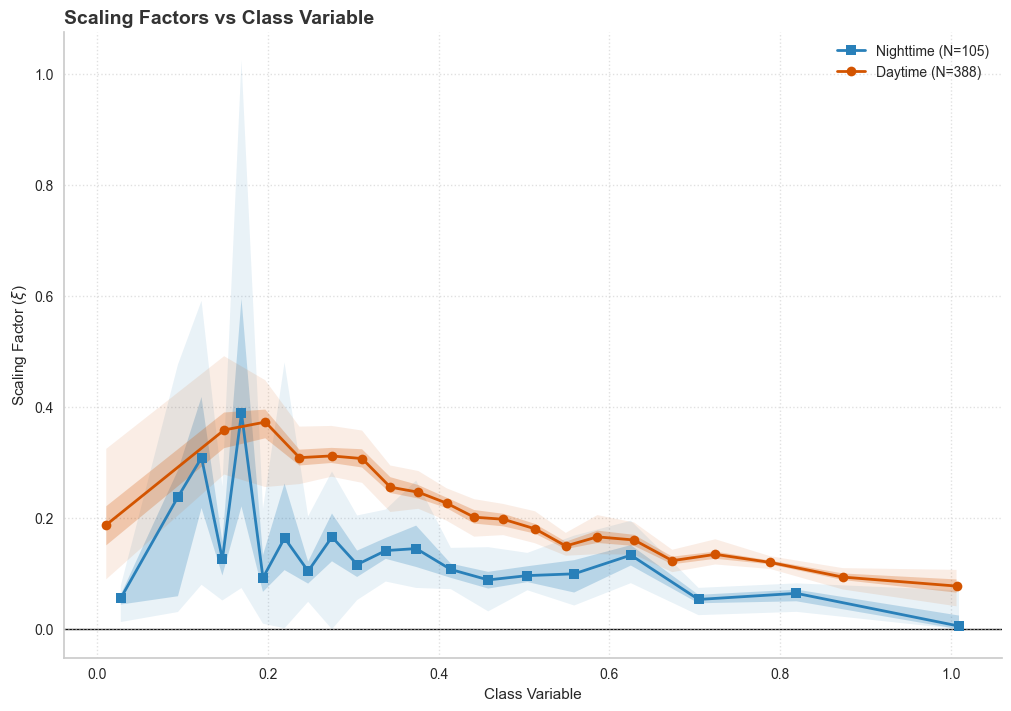

In [10]:
optimizer.plot()

# Correct open-path fluxes with `ScopApplicator`

In [11]:
applicator = ScopApplicator(
    flux_type="CO2",
    fct_unsc=results_physics_df["FCT_UNSC_gfRF"],
    scaling_factors_df=scaling_factors_df,
    flux_openpath=df["NEE_L3.1_L3.2_QCF_IRGA75"].copy(),
    classvar=df["USTAR_IRGA72"].copy(),
    daytime=results_physics_df["DAYTIME"].copy()    
)
applicator.run()

In [12]:
applicator.stats(flux_closedpath=df["NEE_L3.1_L3.2_QCF_IRGA72"])



             FLUX CORRECTION PERFORMANCE REPORT             
Flux Type: CO2        | N Observations: 9,867
------------------------------------------------------------
1. CUMULATIVE BUDGET / TOTALS                    (% of Ref)
............................................................
   Reference (CP)     :      -60,455           (100.0%)
   Uncorrected (OP)   :      -83,744           (138.5%)
 ✓ Corrected (OP)     :      -60,563           (100.2%)


2. ACCURACY (Corrected vs. Reference)                       
............................................................
   RMSE    :    3.860       |   R² Score  :   0.8831
   MAE     :    2.012       |   Slope (m) :    1.002
   Bias    :   -0.011       |   Interc (c):    0.002
------------------------------------------------------------
   Optimization Gain (RMSE Reduction):       16.4%




Generating Comprehensive Flux Dashboard (Large Font Edition)...


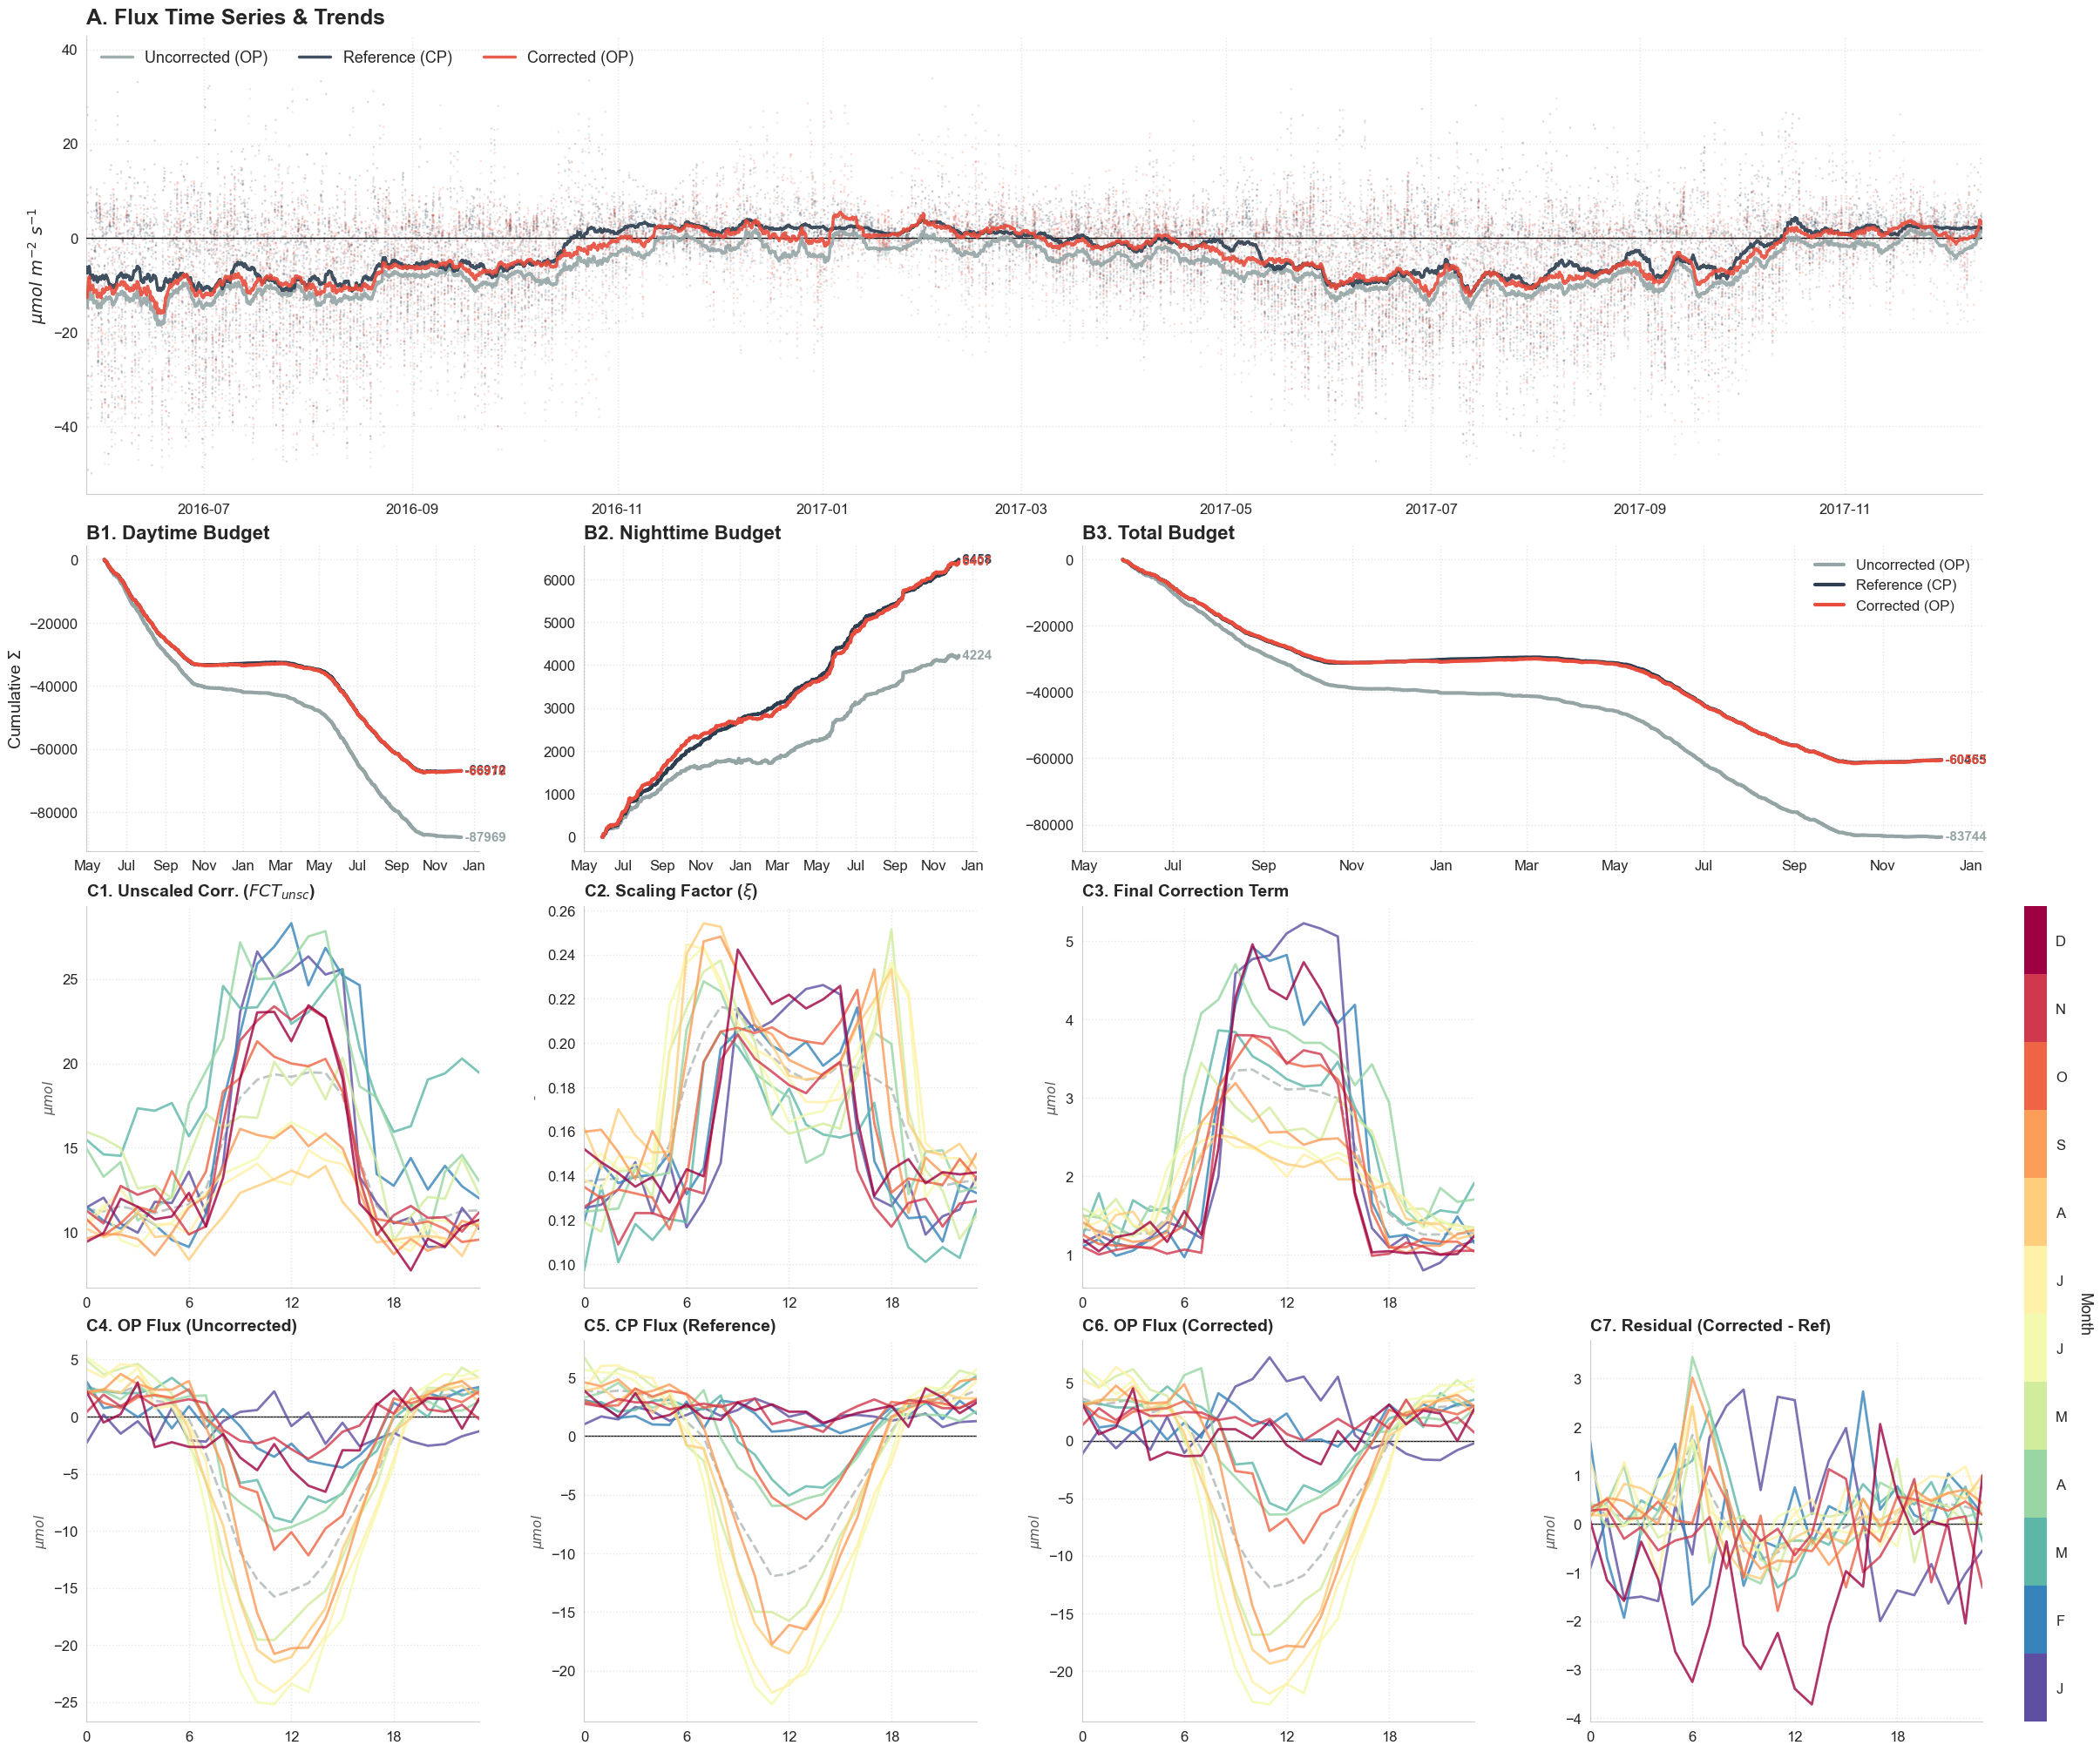

In [13]:
applicator.plot_dashboard(flux_closedpath=df["NEE_L3.1_L3.2_QCF_IRGA72"])

# Scaling factors table

In [14]:
scaling_factors_df

,DAYTIME,GROUP_CLASSVAR,GROUP_CLASSVAR_MIN,GROUP_CLASSVAR_MAX,BOOTSTRAP_RUNS,SF_MEDIAN,SF_Q25,SF_Q75,SF_Q01,SF_Q99,SOS_MEDIAN,NUMVALS_AVG
0,0.0,0.0,0.027716,0.092605,100,0.056168,0.044564,0.062324,0.013046,0.078278,42.326613,36
1,0.0,1.0,0.094653,0.119879,100,0.238439,0.059487,0.286189,0.031037,0.476701,332.129436,32
2,0.0,2.0,0.122276,0.144957,100,0.309048,0.218443,0.418357,0.080136,0.591644,384.737771,38
3,0.0,3.0,0.146694,0.167737,100,0.125893,0.096872,0.157369,0.051833,0.257225,102.041515,39
4,0.0,4.0,0.169055,0.192914,100,0.389207,0.221277,0.595500,0.074262,1.025125,591.698067,45
...,...,...,...,...,...,...,...,...,...,...,...,...
35,1.0,15.0,0.673636,0.724010,100,0.123569,0.116967,0.130817,0.102837,0.143177,7732.748842,426
36,1.0,16.0,0.724078,0.787927,100,0.134933,0.127008,0.139943,0.116712,0.162122,8345.965774,400
37,1.0,17.0,0.788481,0.872671,100,0.120378,0.116947,0.123693,0.108560,0.131513,5018.795664,392
38,1.0,18.0,0.873211,1.004330,100,0.094032,0.088718,0.100579,0.071700,0.110144,6959.287489,382


# Save to file

In [15]:
filename = "32_SelfHeatingCorrection_ScalingFactors_NEE"
scaling_factors_df.to_csv(f"{filename}.csv", index=True)

# ✅END OF NOTEBOOK

In [16]:
dt_string = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
print(f"Finished. {dt_string}")

Finished. 2025-11-29 01:49:06
